In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import warnings, os, gc, re
import matplotlib.pyplot as plt
import psutil
import swifter
from ast import literal_eval

# from plotnine import ggplot, aes, geom_line
from plotnine import *
import plotnine
# import pygal as pg

from kmodes.kprototypes import KPrototypes

%matplotlib inline

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format

In [34]:
df = pd.read_excel('input_ss_3.xlsx')
df.head(10)

,PtNo,AIC,FPG,HPG,RBS,Sex,Age,AgeDx,HxDKA,Retinopathy,...,AntiTG,AntiTPO,GAD,gadfin,ia2cat,ia2fin,insuaa,iaafin,zinccat,zincfin
0,1,1,2,2,2,2,24,24,No,No retinopathy,...,23.9000,0.0000,4.0000,0,9.0000,0,0.3000,0,9.0000,0
1,2,2,1,2,2,2,30,30,No,No retinopathy,...,356.0000,0.0000,4.0000,0,9.0000,0,0.4200,0,9.0000,0
2,3,2,1,2,2,2,22,22,No,No retinopathy,...,129.9000,296.1000,4.0000,0,9.0000,0,0.8100,0,9.0000,0
3,4,2,1,2,2,1,40,40,No,No retinopathy,...,54.3000,0.0000,4.0000,0,9.0000,0,1.6500,1,9.0000,0
4,5,2,1,2,2,2,35,35,No,No retinopathy,...,345.8000,139.3000,4.0000,0,9.0000,0,0.4000,0,9.0000,0
5,6,2,2,1,2,2,42,42,No,No retinopathy,...,27.2000,0.0000,4.0000,0,9.0000,0,0.6400,0,9.0000,0
6,8,2,2,1,2,2,33,33,No,No retinopathy,...,25.5000,0.0000,4.0000,0,9.0000,0,0.3000,0,14.4200,0
7,9,2,1,2,2,1,35,35,No,No retinopathy,...,48.1000,0.0000,4.0000,0,9.0000,0,0.6900,0,9.0000,0
8,10,1,2,2,2,2,45,45,No,No retinopathy,...,32.6000,0.0000,4.0000,0,9.0000,0,0.3700,0,9.0000,0
9,11,1,1,2,2,2,42,42,No,No retinopathy,...,40.2000,2.1000,4.0000,0,9.0000,0,0.4500,0,9.0000,0


In [35]:
len(df.columns)

79

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PtNo           333 non-null    int64  
 1   AIC            333 non-null    int64  
 2   FPG            333 non-null    int64  
 3   HPG            333 non-null    int64  
 4   RBS            333 non-null    int64  
 5   Sex            333 non-null    int64  
 6   Age            333 non-null    int64  
 7   AgeDx          333 non-null    int64  
 8   HxDKA          333 non-null    object 
 9   Retinopathy    333 non-null    object 
 10  Nephropath     333 non-null    object 
 11  Neuropath      333 non-null    object 
 12  CVD            333 non-null    object 
 13  CHD            333 non-null    object 
 14  PAOD           333 non-null    object 
 15  Hypertension   333 non-null    object 
 16  DyslipideMia   333 non-null    object 
 17  Thyroid        333 non-null    object 
 18  Autothytyp

In [37]:
df1 = df.drop(['PtNo'], axis = 1)
df1.head(5)

,AIC,FPG,HPG,RBS,Sex,Age,AgeDx,HxDKA,Retinopathy,Nephropath,...,AntiTG,AntiTPO,GAD,gadfin,ia2cat,ia2fin,insuaa,iaafin,zinccat,zincfin
0,1,2,2,2,2,24,24,No,No retinopathy,No neprhopathy,...,23.9000,0.0000,4.0000,0,9.0000,0,0.3000,0,9.0000,0
1,2,1,2,2,2,30,30,No,No retinopathy,No neprhopathy,...,356.0000,0.0000,4.0000,0,9.0000,0,0.4200,0,9.0000,0
2,2,1,2,2,2,22,22,No,No retinopathy,No neprhopathy,...,129.9000,296.1000,4.0000,0,9.0000,0,0.8100,0,9.0000,0
3,2,1,2,2,1,40,40,No,No retinopathy,No neprhopathy,...,54.3000,0.0000,4.0000,0,9.0000,0,1.6500,1,9.0000,0
4,2,1,2,2,2,35,35,No,No retinopathy,No neprhopathy,...,345.8000,139.3000,4.0000,0,9.0000,0,0.4000,0,9.0000,0


In [38]:
column_categ = ['AIC', 'FPG', 'HPG', 'RBS', 'Sex', 'HxDKA', 'Retinopathy', 'Nephropath', 'Neuropath', 'CVD', 'CHD',
'PAOD', 'Hypertension', 'DyslipideMia', 'Thyroid', 'Autothytype', 'MetSyndrome', 'MSWC', 'Trigly', 'HDL', 'BP',
'T2DM', 't2dm _int', 'bmicat', 'obese', 'Acanthosis', 'ABIRight', 'ABILeft', 'MonoFil', 'homa', 'egdrcat', 'matsuda',
'gadfin', 'ia2fin', 'zincfin', 'iaafin', 'AG']

for col in column_categ:
    df1[col] = df1[col].astype('category')

In [39]:
# enumerate rows with categorical data 
catColumnsPos = [df1.columns.get_loc(col) for col in list(df1.select_dtypes('category').columns)]
print(catColumnsPos)

[0, 1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 30, 34, 35, 36, 37, 38, 60, 62, 64, 66, 71, 73, 75, 77]


In [40]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 78 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   AIC            333 non-null    category
 1   FPG            333 non-null    category
 2   HPG            333 non-null    category
 3   RBS            333 non-null    category
 4   Sex            333 non-null    category
 5   Age            333 non-null    int64   
 6   AgeDx          333 non-null    int64   
 7   HxDKA          333 non-null    category
 8   Retinopathy    333 non-null    category
 9   Nephropath     333 non-null    category
 10  Neuropath      333 non-null    category
 11  CVD            333 non-null    category
 12  CHD            333 non-null    category
 13  PAOD           333 non-null    category
 14  Hypertension   333 non-null    category
 15  DyslipideMia   333 non-null    category
 16  Thyroid        333 non-null    category
 17  Autothytype    333 non-null    cate

In [51]:
column_to_std = ['Age', 'AgeDx', 'SBP', 'DBP', 'Wt', 'Ht', 'BMI', 'AbdCirc', 'HipCirc', 'WHR', 'OGTTfast', 'OGTT1H', 'OGTT2H',
'MeanOGTT', 'Insufast', 'insu1h_comb', 'insu2h_comb', 'mean_ins_comb', 'cpep_comb', 'creanum', 'Screa', 'HbA1c', 'ALT',
'Tchol', 'Trig', 'LDL', 'HDLNUM', 'ft4num', 'tshnum', 'leptin', 'adinum', 'HOMAIR', 'egdr', 'MatsudaInex', 'Quicki', 
'AntiTG', 'AntiTPO', 'GAD', 'ia2cat', 'insuaa', 'zinccat'] 

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

df_vals = df1[column_to_std]

# scaler = preprocessing.RobustScaler(quantile_range=(25.0, 75.0))
scaler = preprocessing.StandardScaler()
robust_df = scaler.fit_transform(df_vals.values)
# robust_df = pd.DataFrame(robust_df, columns=column_to_std)

df1[column_to_std] = robust_df 

In [52]:
dfMatrix = df1.to_numpy()
dfMatrix

array([[1, 2, 2, ..., 0, -0.10380414641526448, 0],
       [2, 1, 2, ..., 0, -0.10380414641526448, 0],
       [2, 1, 2, ..., 0, -0.10380414641526448, 0],
       ...,
       [1, 1, 2, ..., 1, -0.10380414641526448, 0],
       [2, 1, 2, ..., 0, -0.10380414641526448, 0],
       [2, 1, 1, ..., 0, -0.10380414641526448, 0]], dtype=object)

Cluster initiation: 1
Cluster initiation: 2
Cluster initiation: 3
Cluster initiation: 4
Cluster initiation: 5
Cluster initiation: 6
Cluster initiation: 7
Cluster initiation: 8
Cluster initiation: 9


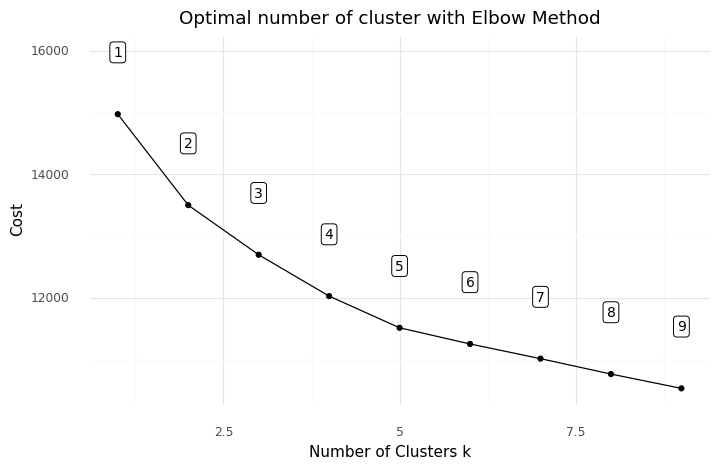

<ggplot: (154433996897)>

In [64]:
# Choose optimal K using Elbow method
cost = []
for cluster in range(1, 10):
    try:
        kprototype = KPrototypes(n_jobs = -1, n_clusters = cluster, init = 'Huang', random_state = 0)
        kprototype.fit_predict(dfMatrix, categorical = catColumnsPos)
        cost.append(kprototype.cost_)
        print('Cluster initiation: {}'.format(cluster))
    except:
        break
# Converting the results into a dataframe and plotting them
df_cost = pd.DataFrame({'Cluster':range(1, 10), 'Cost':cost})
# Data viz
plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_cost)+
    geom_line(aes(x = 'Cluster',
                  y = 'Cost'))+
    geom_point(aes(x = 'Cluster',
                   y = 'Cost'))+
    geom_label(aes(x = 'Cluster',
                   y = 'Cost',
                   label = 'Cluster'),
               size = 10,
               nudge_y = 1000) +
    labs(title = 'Optimal number of cluster with Elbow Method')+
    xlab('Number of Clusters k')+
    ylab('Cost')+
    theme_minimal()
)

In [65]:
# Fit the cluster; based on above plot, elbow is on cluster = 5
kprototype = KPrototypes(n_jobs = -1, n_clusters = 5, init = 'Huang', random_state = 0)
kprototype.fit_predict(dfMatrix, categorical = catColumnsPos)

array([0, 3, 2, 0, 2, 2, 0, 0, 3, 3, 0, 3, 3, 3, 3, 2, 2, 3, 3, 2, 2, 3,
       0, 2, 2, 3, 3, 2, 0, 2, 2, 2, 3, 0, 2, 0, 2, 3, 2, 0, 2, 3, 3, 3,
       2, 2, 1, 2, 0, 3, 0, 2, 2, 3, 3, 2, 1, 3, 2, 2, 0, 2, 3, 3, 0, 2,
       2, 1, 3, 1, 2, 0, 3, 3, 1, 2, 3, 3, 1, 2, 3, 1, 0, 3, 3, 3, 3, 0,
       0, 3, 4, 2, 1, 3, 3, 2, 3, 1, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2,
       3, 2, 1, 2, 3, 3, 0, 2, 0, 3, 0, 3, 1, 2, 3, 1, 2, 0, 2, 1, 3, 3,
       2, 1, 2, 1, 3, 2, 3, 3, 3, 3, 3, 2, 1, 1, 2, 3, 2, 3, 3, 2, 1, 1,
       1, 1, 1, 0, 2, 3, 0, 3, 3, 4, 2, 3, 3, 2, 3, 3, 2, 3, 0, 2, 1, 2,
       2, 3, 1, 1, 1, 3, 3, 1, 2, 0, 3, 0, 1, 3, 3, 2, 3, 2, 3, 3, 0, 1,
       3, 0, 0, 3, 3, 2, 3, 3, 0, 3, 1, 3, 3, 3, 2, 3, 0, 2, 1, 1, 3, 3,
       3, 0, 1, 1, 3, 2, 2, 2, 3, 2, 0, 3, 0, 1, 1, 0, 0, 0, 2, 1, 2, 2,
       2, 3, 3, 4, 2, 3, 1, 3, 3, 3, 0, 3, 0, 0, 2, 1, 3, 1, 3, 3, 0, 1,
       0, 3, 3, 3, 1, 2, 0, 3, 2, 0, 3, 2, 2, 0, 3, 2, 2, 2, 3, 0, 0, 1,
       1, 0, 3, 2, 0, 3, 3, 3, 3, 3, 3, 3, 3, 2, 0,

In [66]:
# Cluster centorid
kprototype.cluster_centroids_
# Check the iteration of the clusters created
kprototype.n_iter_
# Check the cost of the clusters created
kprototype.cost_

11519.247341367814

In [67]:
# attach the clusters to df
# Add the cluster to the dataframe
df['Cluster Labels'] = kprototype.labels_
df['Segment'] = df['Cluster Labels'].map({0:'First', 1:'Second', 2:'Third', 3:'Fourth', 4:'Fifth'})
# Order the cluster
df['Segment'] = df['Segment'].astype('category')
df['Segment'] = df['Segment'].cat.reorder_categories(['First','Second','Third', 'Fourth', 'Fifth'])
df.head(10)

,PtNo,AIC,FPG,HPG,RBS,Sex,Age,AgeDx,HxDKA,Retinopathy,...,GAD,gadfin,ia2cat,ia2fin,insuaa,iaafin,zinccat,zincfin,Cluster Labels,Segment
0,1,1,2,2,2,2,24,24,No,No retinopathy,...,4.0000,0,9.0000,0,0.3000,0,9.0000,0,0,First
1,2,2,1,2,2,2,30,30,No,No retinopathy,...,4.0000,0,9.0000,0,0.4200,0,9.0000,0,3,Fourth
2,3,2,1,2,2,2,22,22,No,No retinopathy,...,4.0000,0,9.0000,0,0.8100,0,9.0000,0,2,Third
3,4,2,1,2,2,1,40,40,No,No retinopathy,...,4.0000,0,9.0000,0,1.6500,1,9.0000,0,0,First
4,5,2,1,2,2,2,35,35,No,No retinopathy,...,4.0000,0,9.0000,0,0.4000,0,9.0000,0,2,Third
5,6,2,2,1,2,2,42,42,No,No retinopathy,...,4.0000,0,9.0000,0,0.6400,0,9.0000,0,2,Third
6,8,2,2,1,2,2,33,33,No,No retinopathy,...,4.0000,0,9.0000,0,0.3000,0,14.4200,0,0,First
7,9,2,1,2,2,1,35,35,No,No retinopathy,...,4.0000,0,9.0000,0,0.6900,0,9.0000,0,0,First
8,10,1,2,2,2,2,45,45,No,No retinopathy,...,4.0000,0,9.0000,0,0.3700,0,9.0000,0,3,Fourth
9,11,1,1,2,2,2,42,42,No,No retinopathy,...,4.0000,0,9.0000,0,0.4500,0,9.0000,0,3,Fourth


### Import Seaborn to plot graphs

In [70]:
import seaborn as sns

### First Segment, Non-Categ columns only

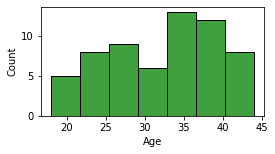

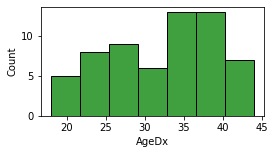

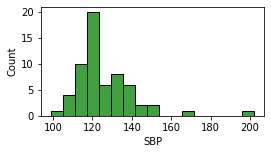

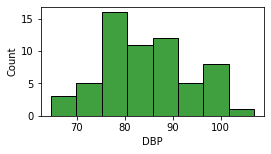

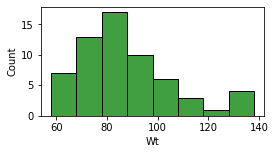

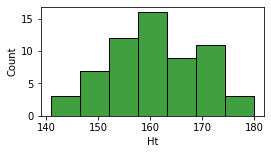

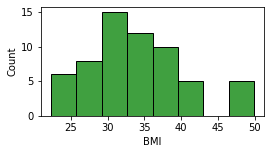

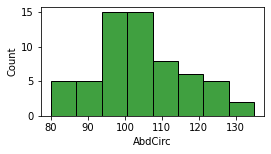

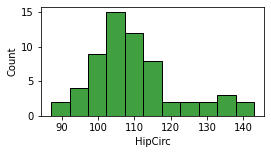

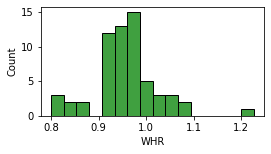

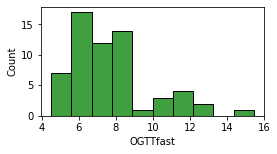

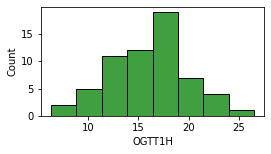

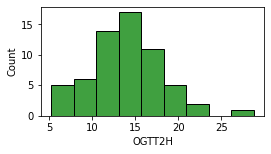

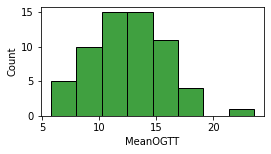

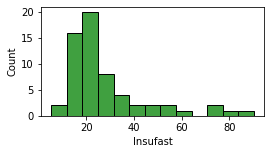

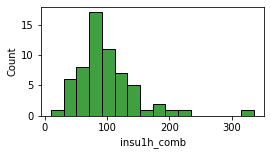

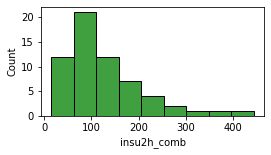

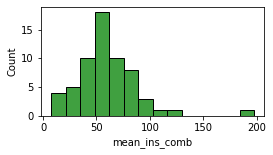

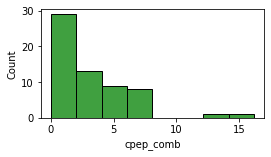

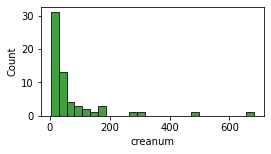

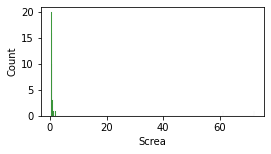

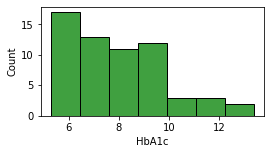

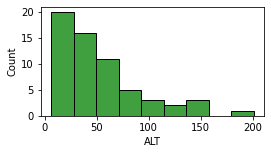

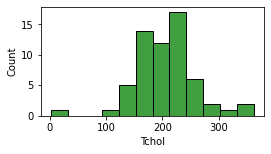

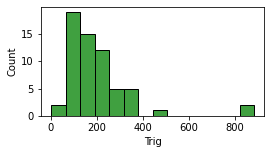

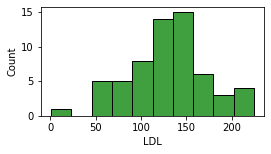

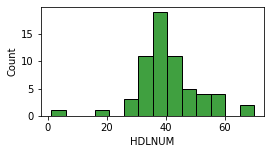

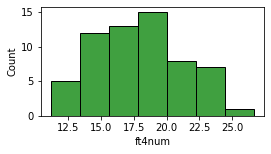

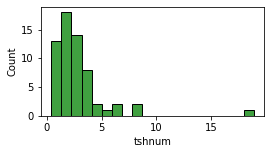

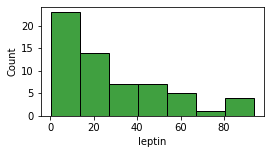

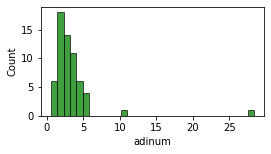

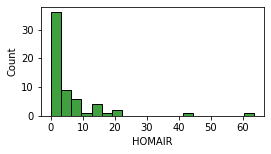

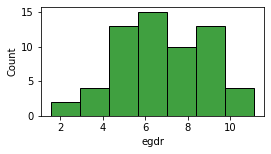

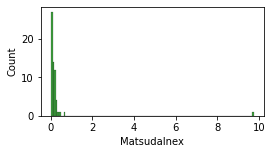

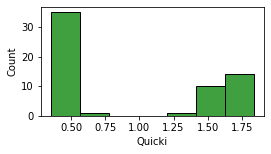

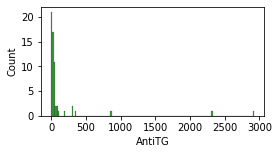

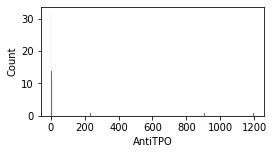

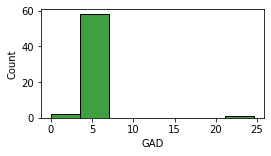

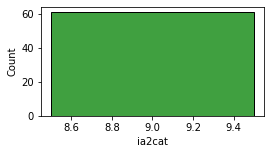

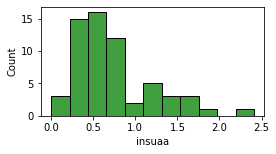

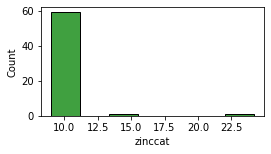

In [71]:
numeric_features=[x for x in column_to_std]
df_first = df[df['Segment'] == 'First']
#taking only the numeric columns from the dataframe.

for i in df_first[numeric_features].columns:
    plt.figure(figsize=(4,2))
#     plt.title(i)
    sns.histplot(data=df_first[i], color='g')

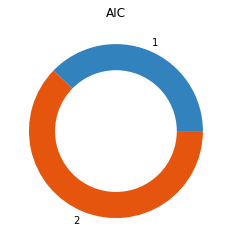

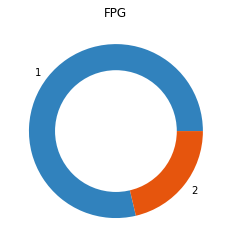

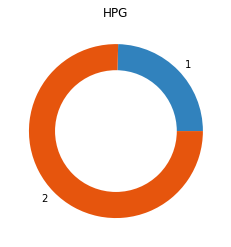

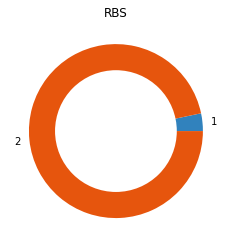

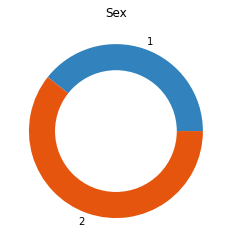

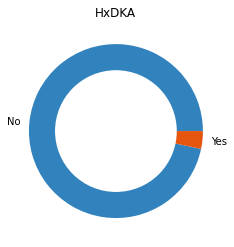

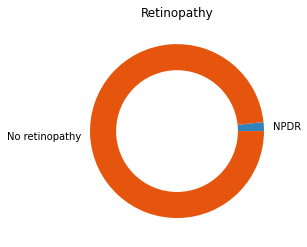

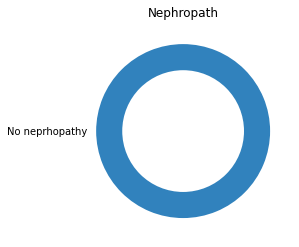

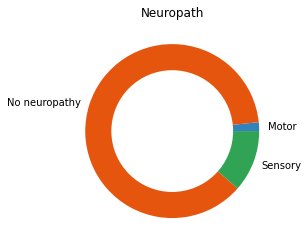

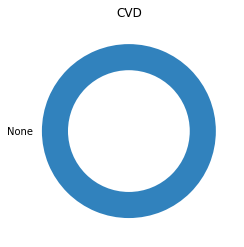

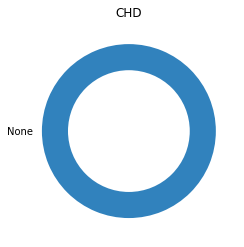

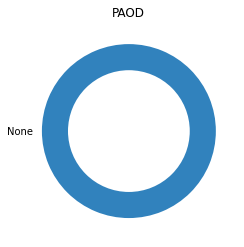

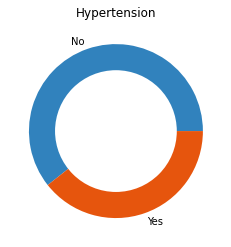

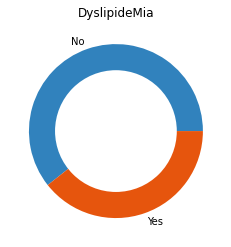

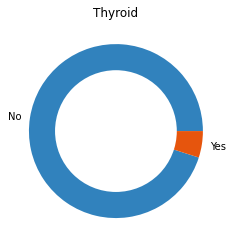

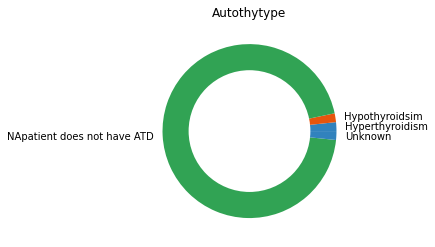

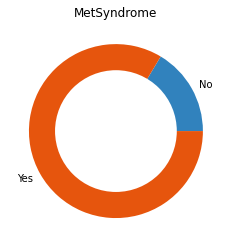

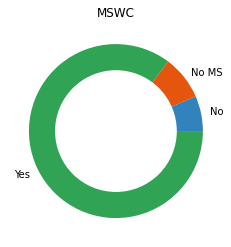

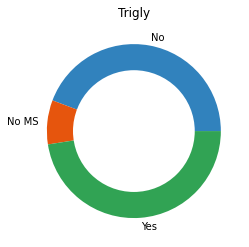

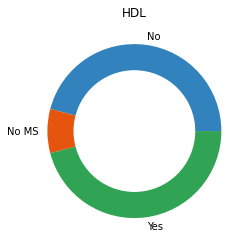

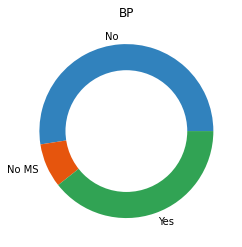

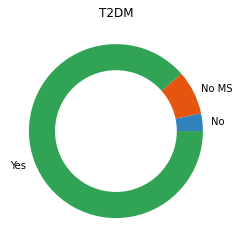

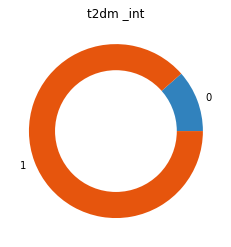

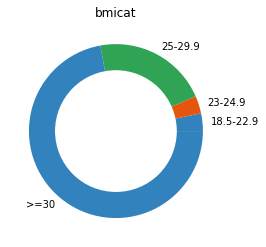

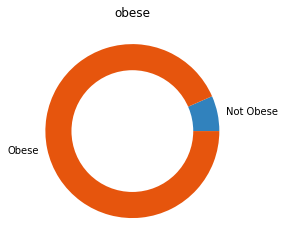

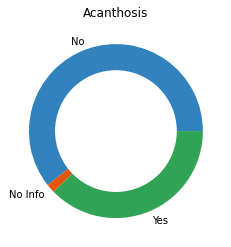

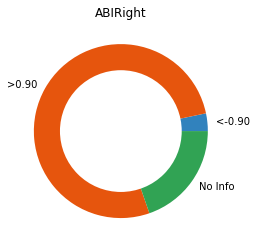

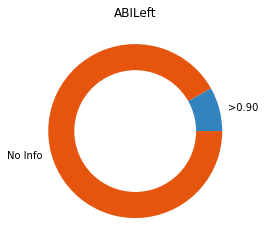

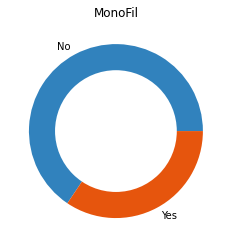

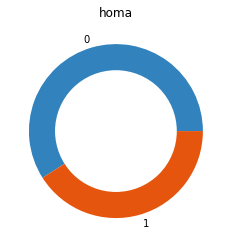

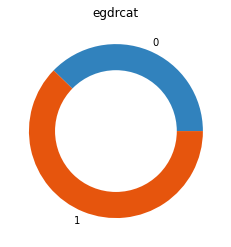

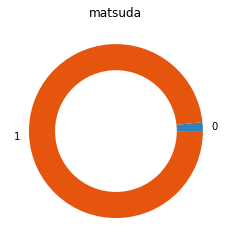

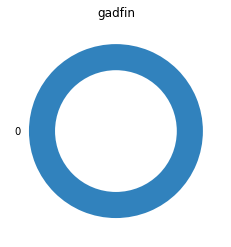

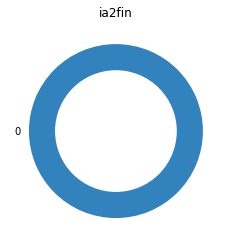

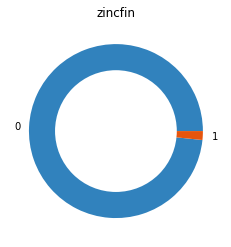

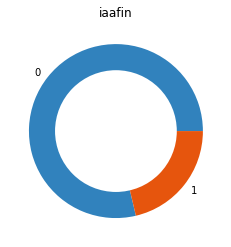

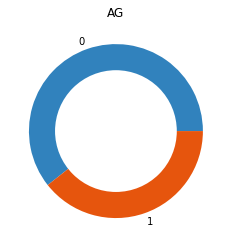

<Figure size 432x288 with 0 Axes>

In [118]:
for cols in column_categ:
    groupx = df_first.groupby([cols])[cols].count()
    cmap = plt.get_cmap("tab20c")
    plt.pie(groupx, labels=groupx.keys(), colors=cmap(np.arange(3)*4))
#     plt.set_color_cycle(['red', 'black', 'yellow'])
    
    # draw circle
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()

    # Adding Circle in Pie chart
    fig.gca().add_artist(centre_circle)
    plt.title(cols)
    plt.figure().clear()

### Second Segment, Non-Categ columns only

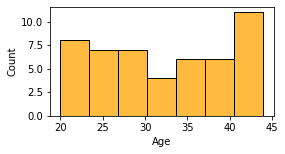

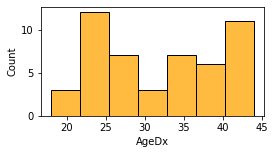

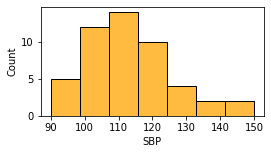

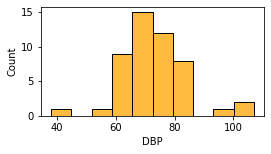

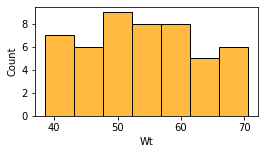

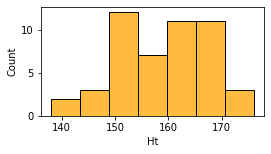

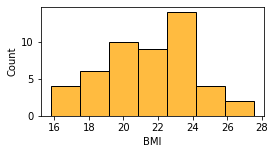

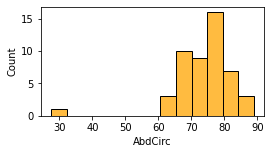

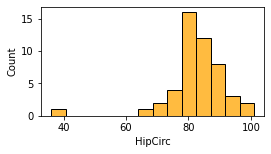

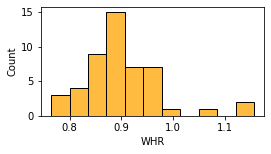

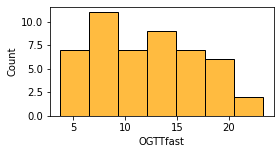

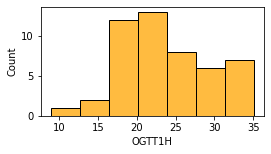

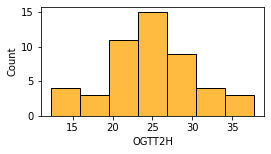

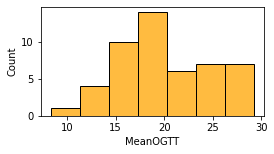

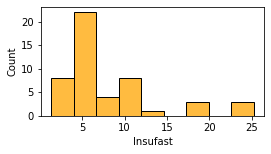

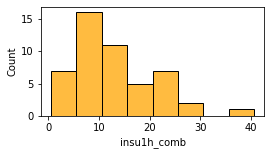

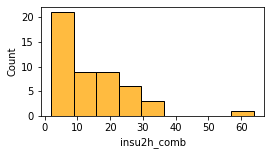

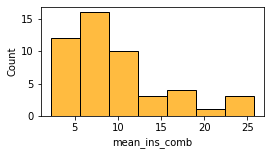

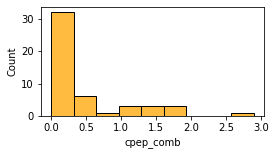

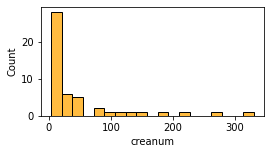

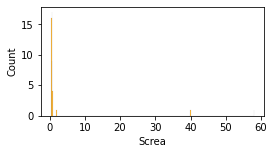

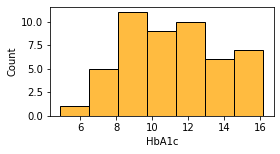

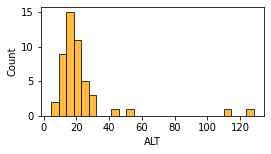

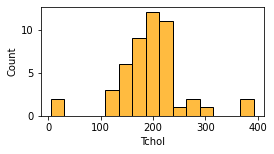

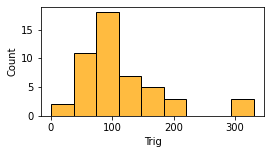

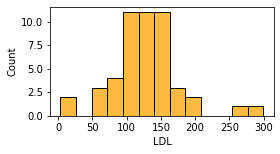

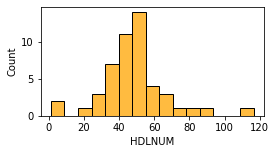

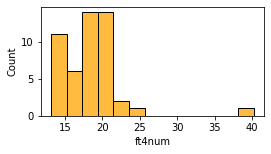

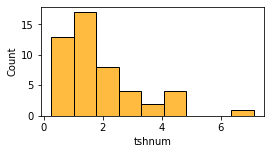

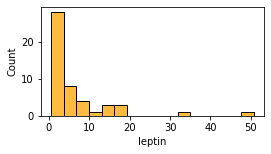

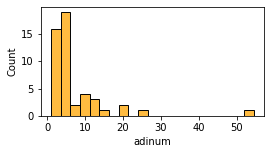

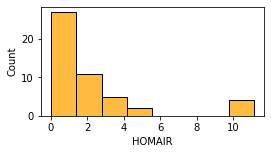

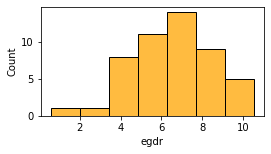

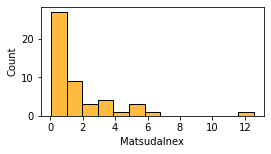

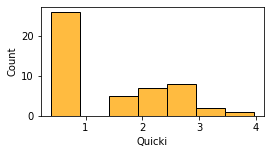

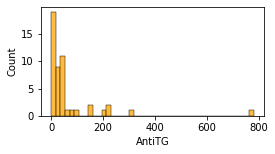

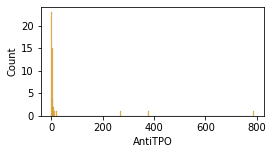

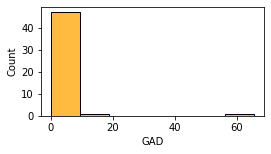

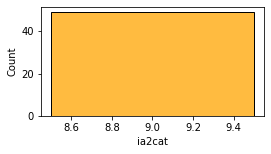

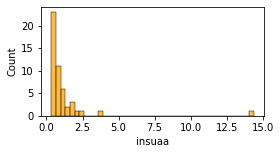

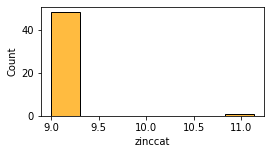

In [72]:
# numeric_features=[x for x in column_to_std]
df_second = df[df['Segment'] == 'Second']
#taking only the numeric columns from the dataframe.

for i in df_second[numeric_features].columns:
    plt.figure(figsize=(4,2))
#     plt.title(i)
    sns.histplot(data=df_second[i], color='orange')

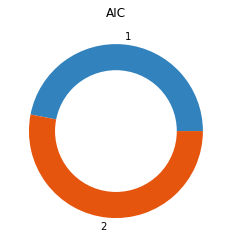

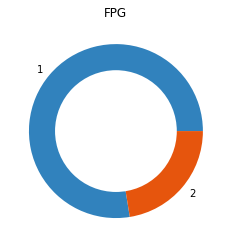

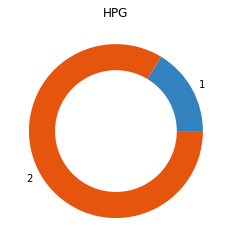

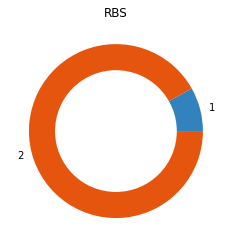

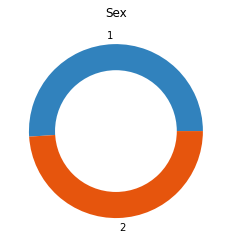

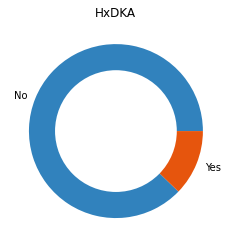

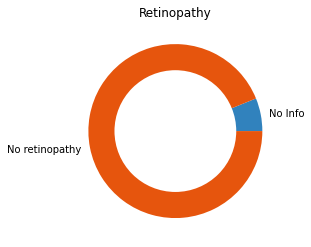

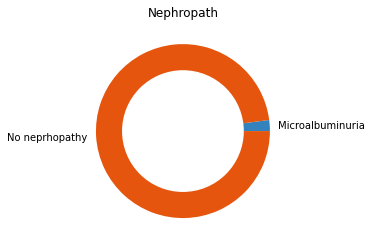

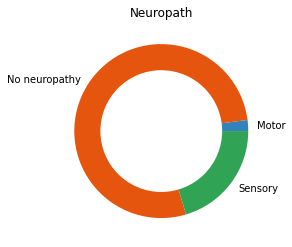

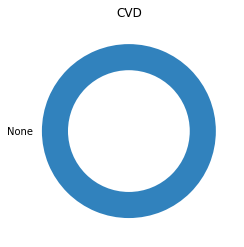

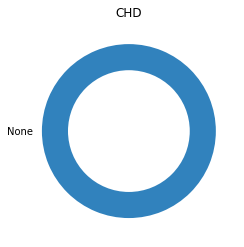

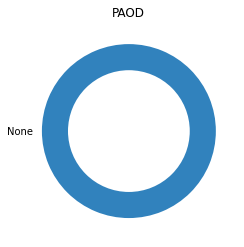

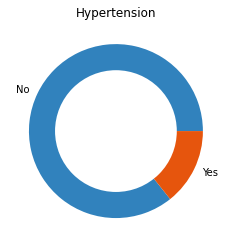

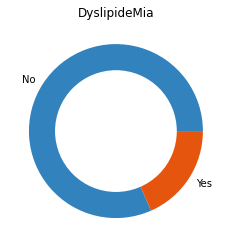

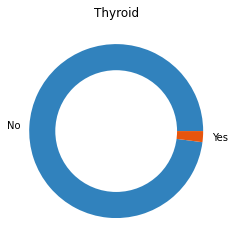

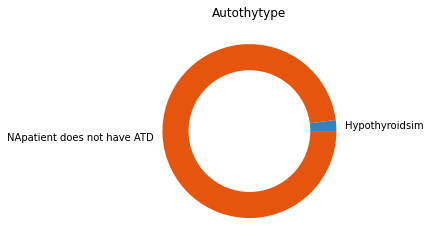

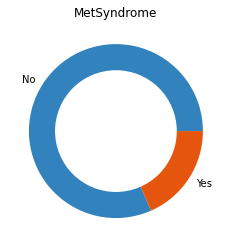

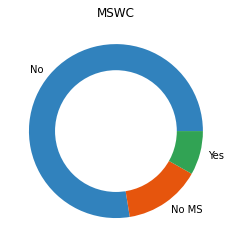

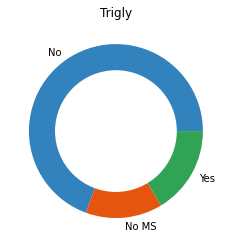

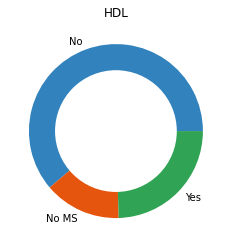

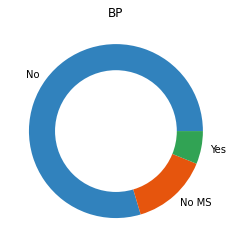

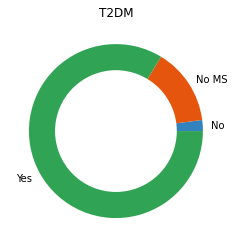

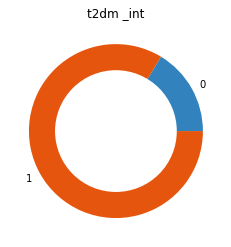

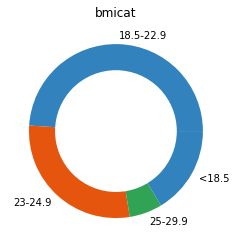

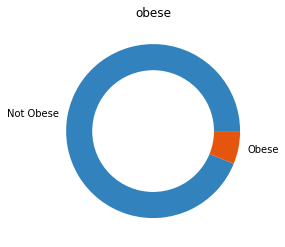

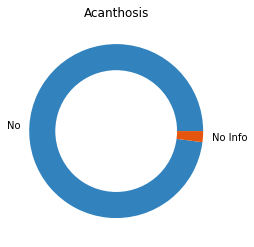

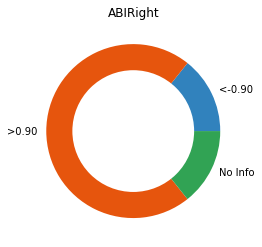

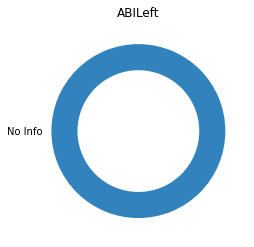

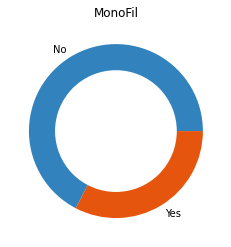

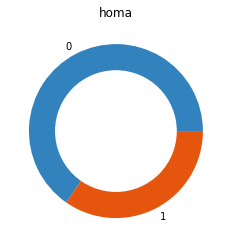

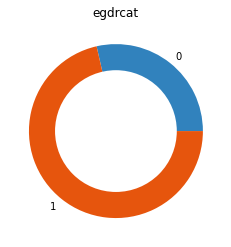

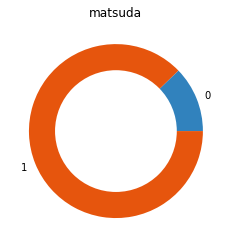

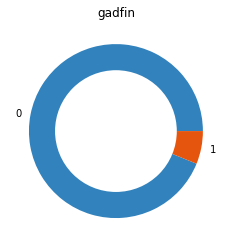

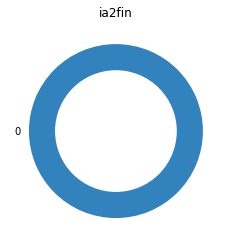

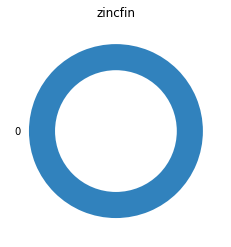

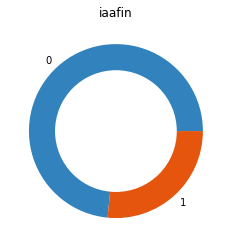

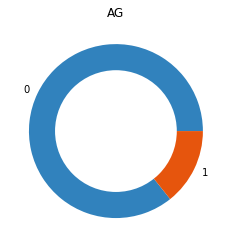

<Figure size 432x288 with 0 Axes>

In [119]:
for cols in column_categ:
    groupx = df_second.groupby([cols])[cols].count()
    cmap = plt.get_cmap("tab20c")
    plt.pie(groupx, labels=groupx.keys(), colors=cmap(np.arange(3)*4))
#     plt.set_color_cycle(['red', 'black', 'yellow'])
    
    # draw circle
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()

    # Adding Circle in Pie chart
    fig.gca().add_artist(centre_circle)
    plt.title(cols)
    plt.figure().clear()

### Third Segment, Non-Categ columns only

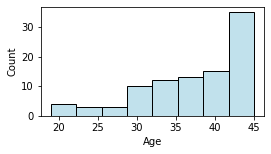

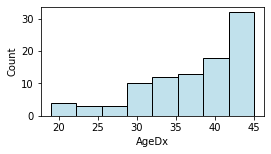

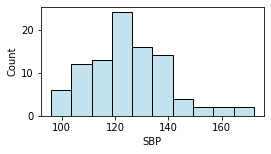

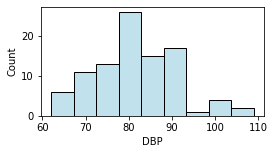

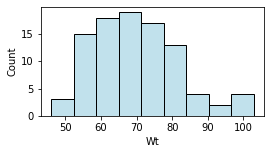

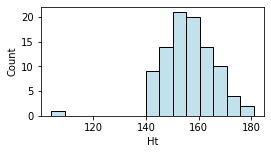

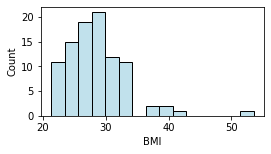

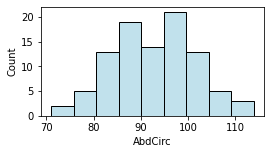

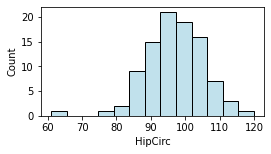

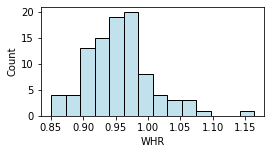

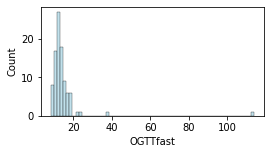

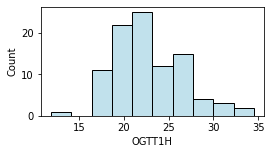

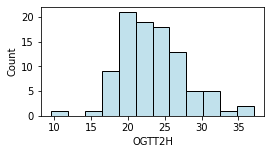

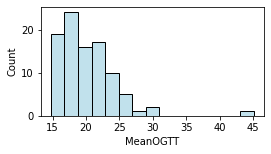

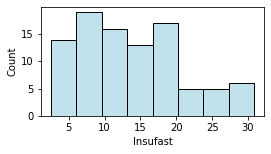

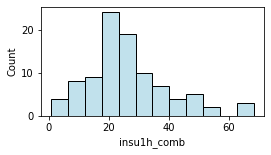

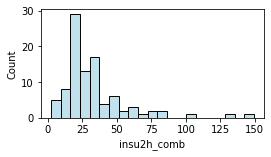

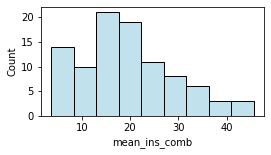

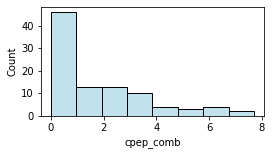

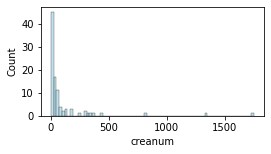

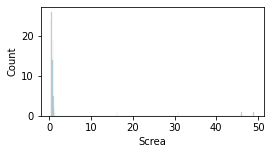

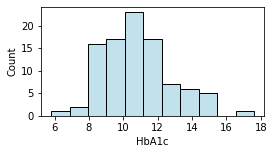

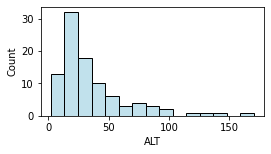

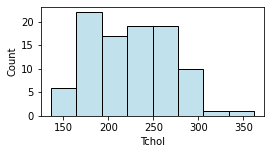

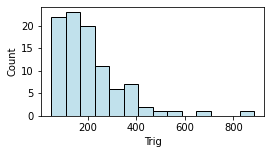

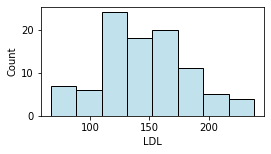

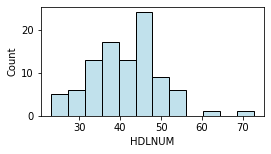

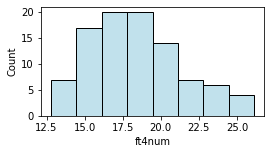

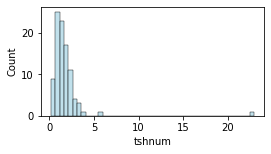

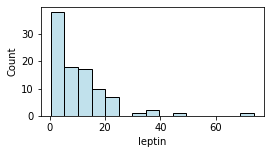

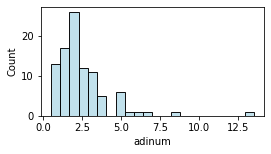

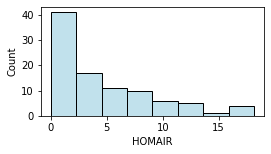

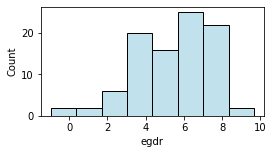

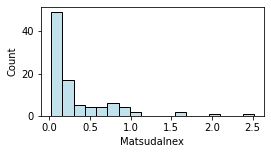

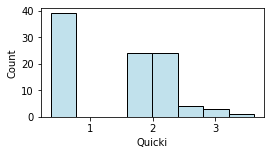

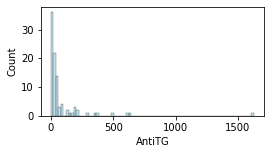

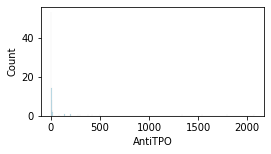

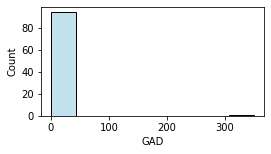

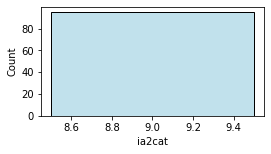

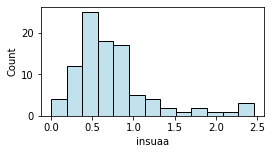

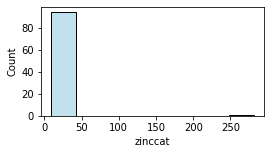

In [122]:
df_third = df[df['Segment'] == 'Third']
#taking only the numeric columns from the dataframe.

for i in df_third[numeric_features].columns:
    plt.figure(figsize=(4,2))
#     plt.title(i)
    sns.histplot(data=df_third[i], color='lightblue')

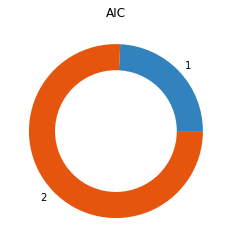

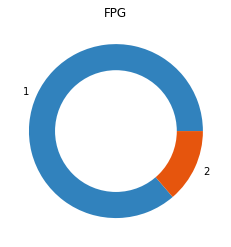

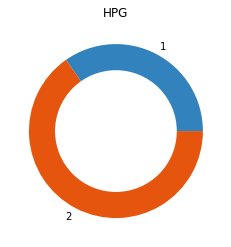

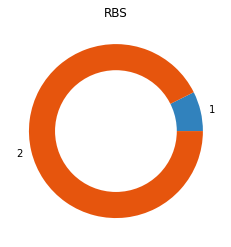

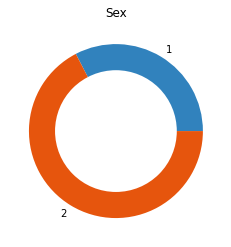

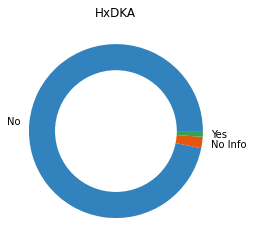

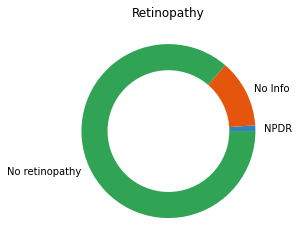

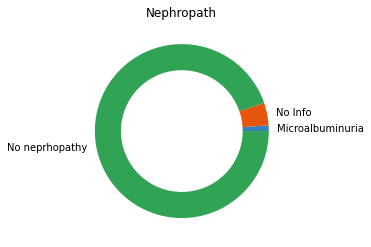

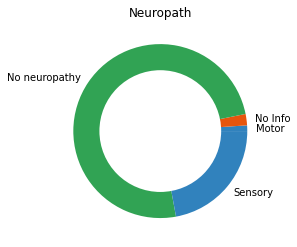

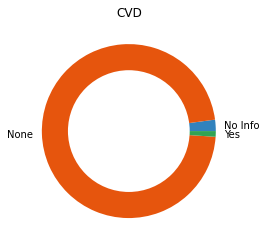

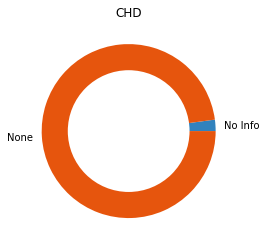

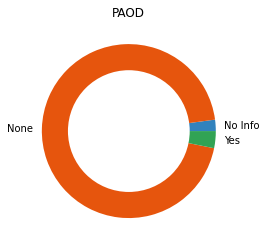

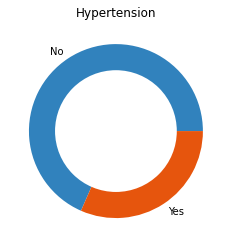

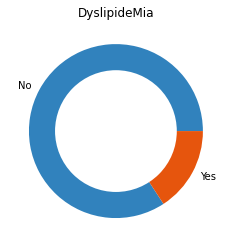

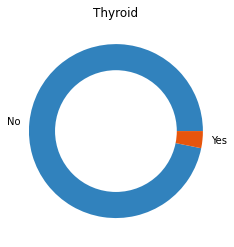

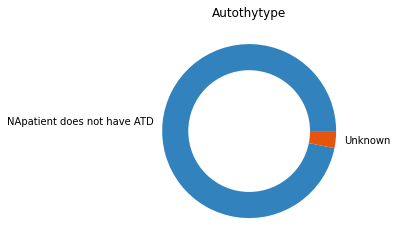

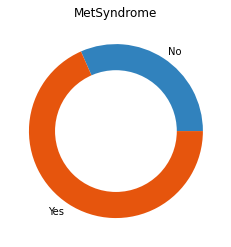

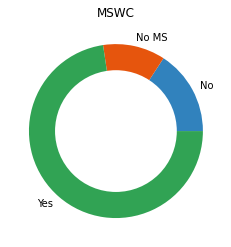

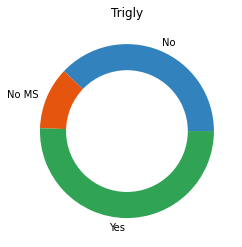

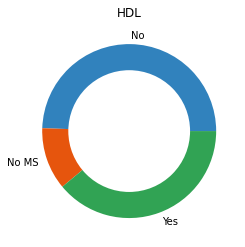

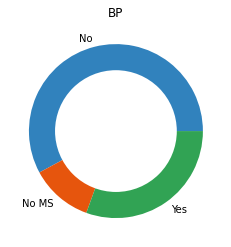

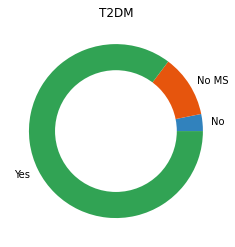

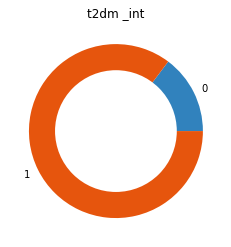

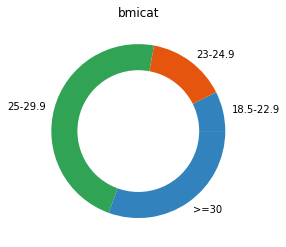

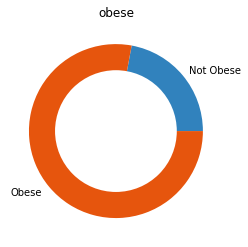

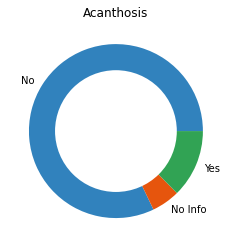

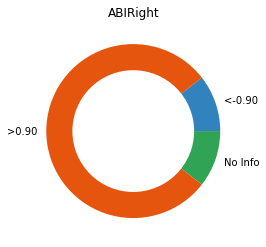

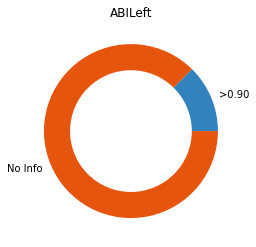

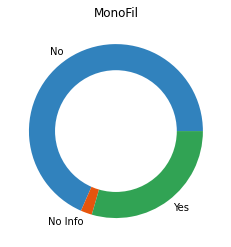

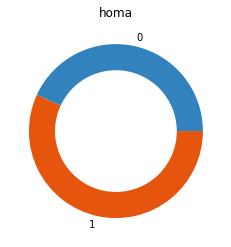

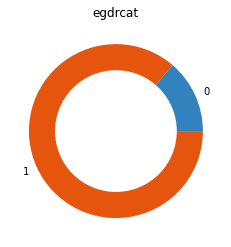

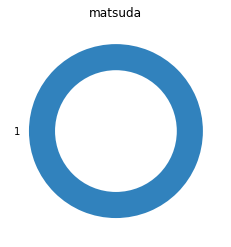

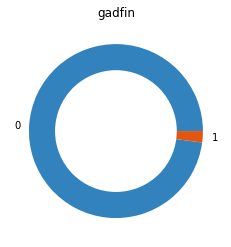

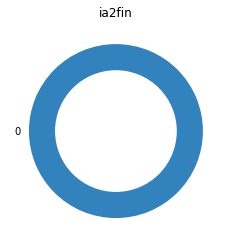

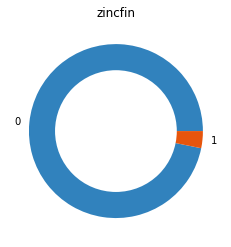

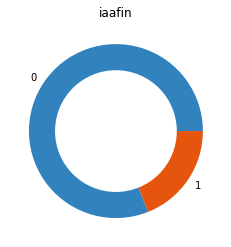

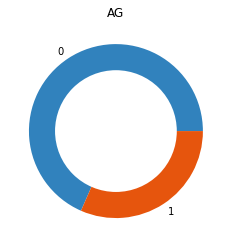

<Figure size 432x288 with 0 Axes>

In [132]:
for cols in column_categ:
    groupx = df_third.groupby([cols])[cols].count()

#     def absolute_value(val):
#         a = np.round(val/100.*groupx.sum(), 0)
#         return a

    cmap = plt.get_cmap("tab20c")
    plt.pie(groupx, labels=groupx.keys(), colors=cmap(np.arange(3)*4)) 
#     plt.pie(groupx, labels=groupx.keys(), colors=cmap(np.arange(3)*4), 
#             autopct=absolute_value)
    
    # draw circle
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()

    # Adding Circle in Pie chart
    fig.gca().add_artist(centre_circle)
    plt.title(cols)
    plt.figure().clear()

### Fourth Segment, Non-Categ columns only

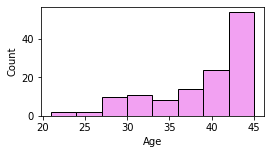

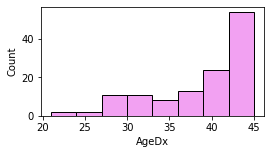

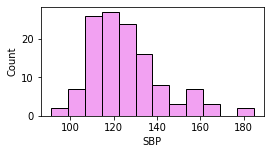

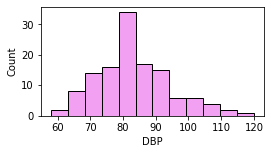

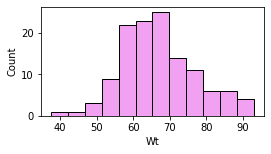

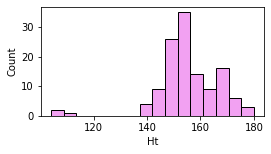

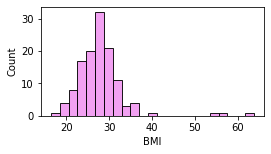

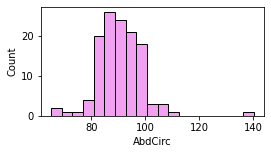

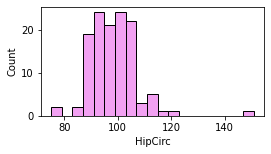

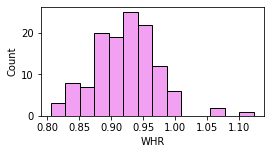

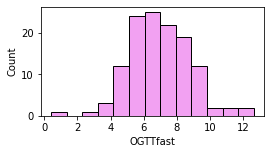

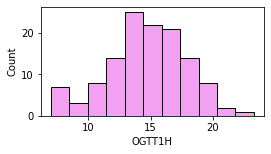

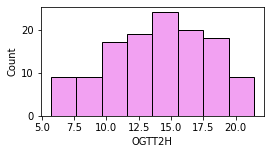

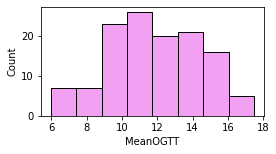

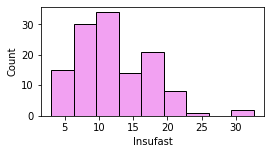

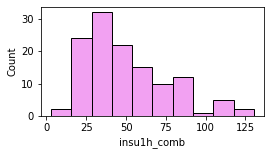

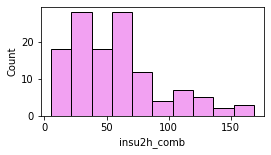

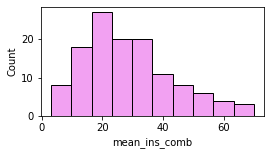

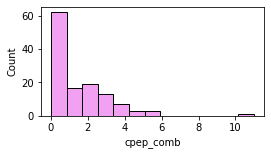

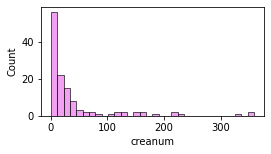

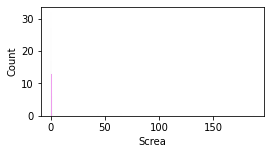

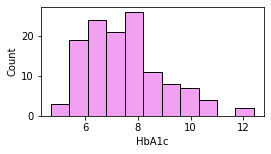

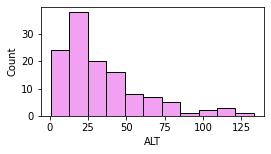

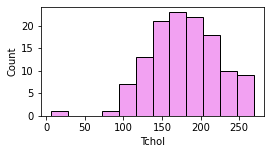

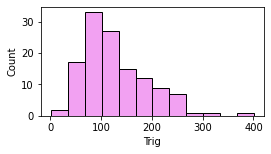

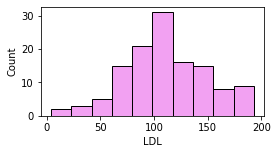

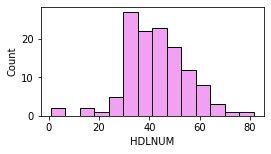

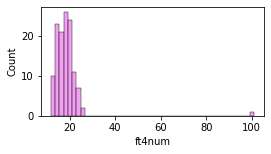

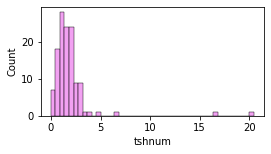

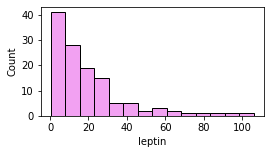

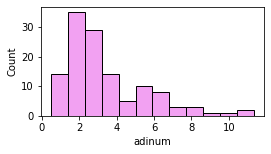

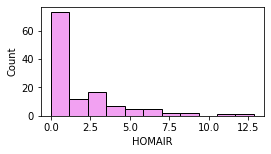

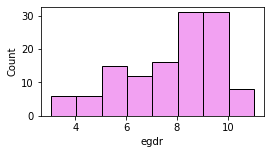

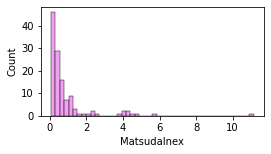

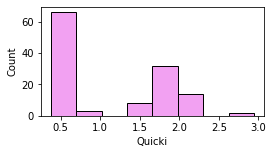

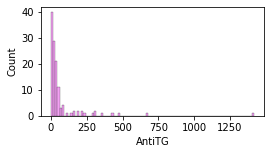

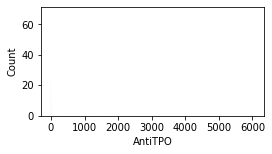

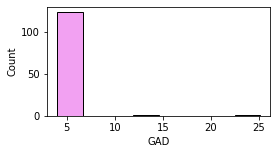

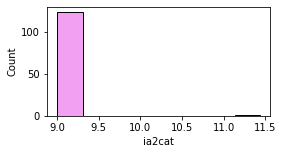

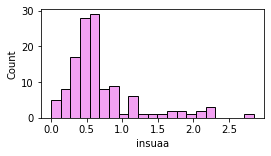

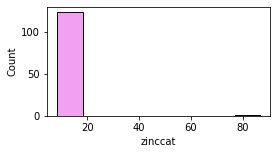

In [134]:
df_fourth = df[df['Segment'] == 'Fourth']
#taking only the numeric columns from the dataframe.

for i in df_fourth[numeric_features].columns:
    plt.figure(figsize=(4,2))
#     plt.title(i)
    sns.histplot(data=df_fourth[i], color='violet')

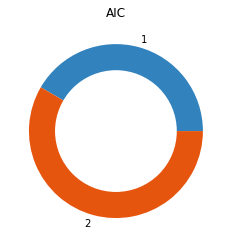

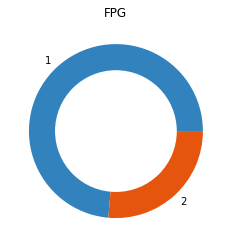

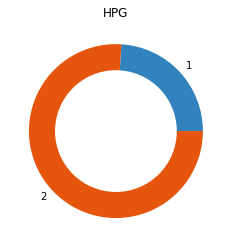

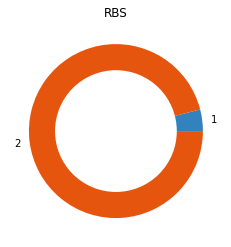

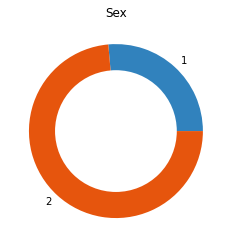

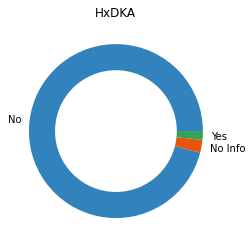

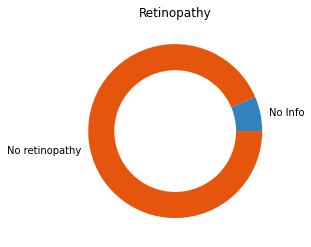

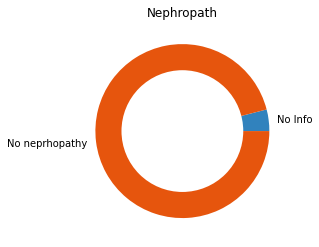

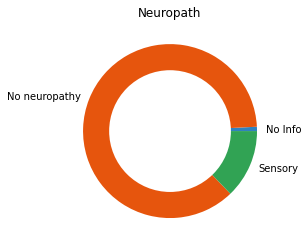

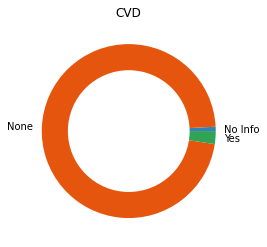

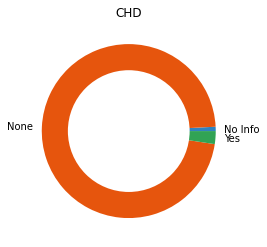

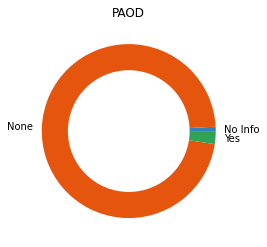

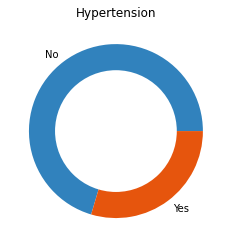

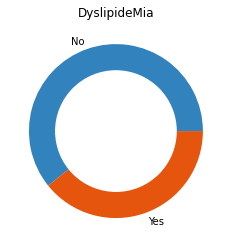

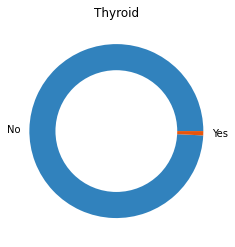

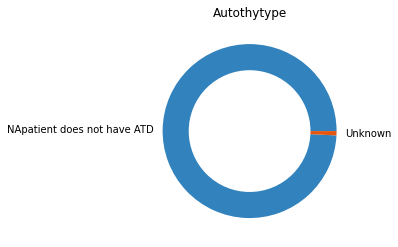

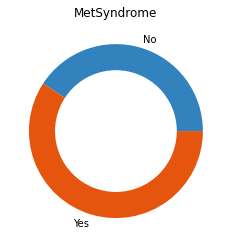

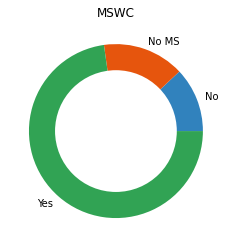

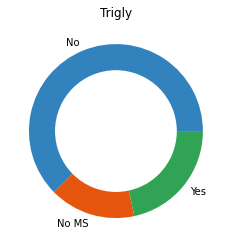

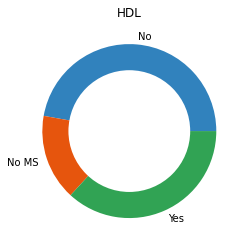

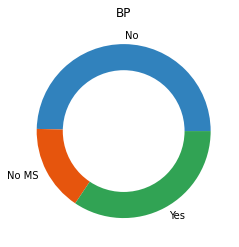

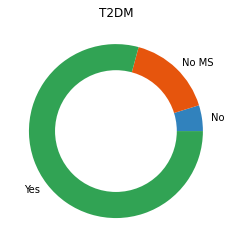

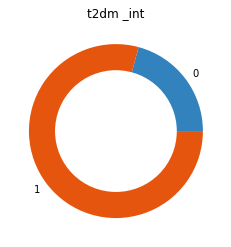

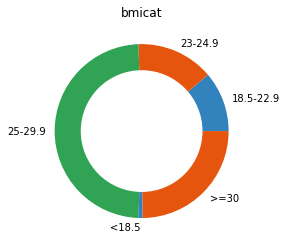

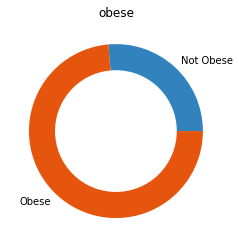

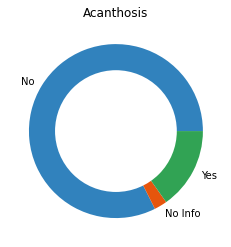

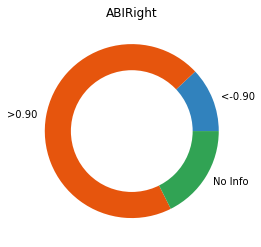

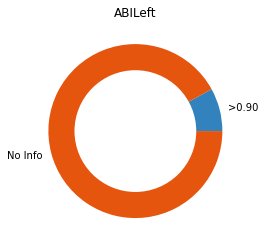

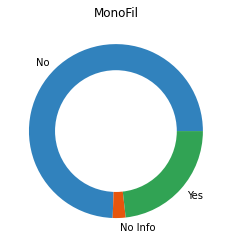

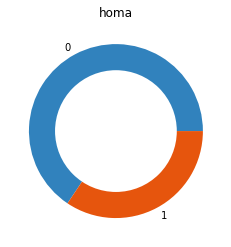

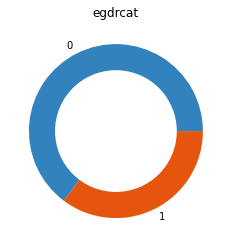

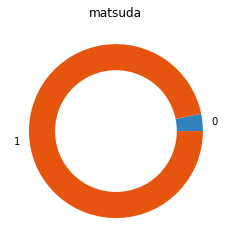

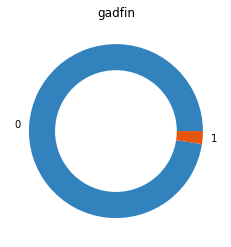

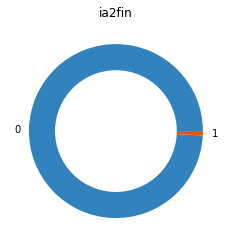

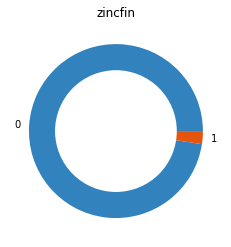

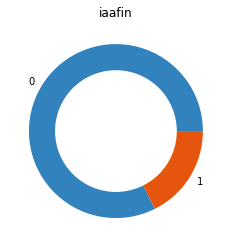

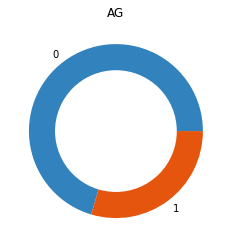

<Figure size 432x288 with 0 Axes>

In [135]:
for cols in column_categ:
    groupx = df_fourth.groupby([cols])[cols].count()

#     def absolute_value(val):
#         a = np.round(val/100.*groupx.sum(), 0)
#         return a

    cmap = plt.get_cmap("tab20c")
    plt.pie(groupx, labels=groupx.keys(), colors=cmap(np.arange(3)*4)) 
#     plt.pie(groupx, labels=groupx.keys(), colors=cmap(np.arange(3)*4), 
#             autopct=absolute_value)
    
    # draw circle
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()

    # Adding Circle in Pie chart
    fig.gca().add_artist(centre_circle)
    plt.title(cols)
    plt.figure().clear()

### Fifth Segment, Non-Categ columns only

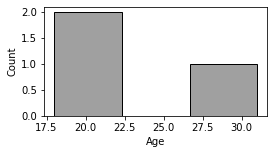

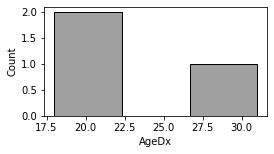

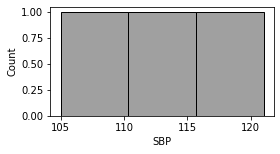

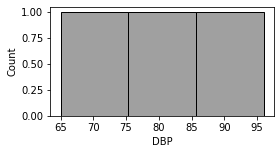

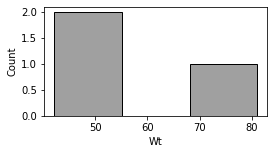

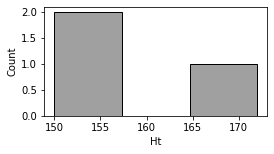

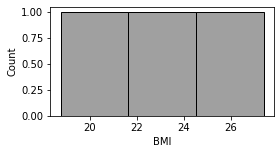

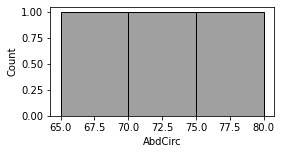

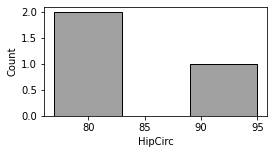

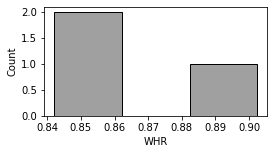

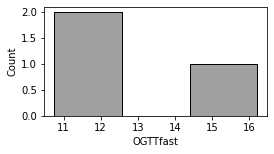

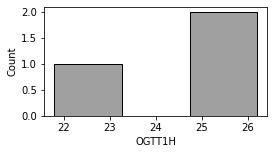

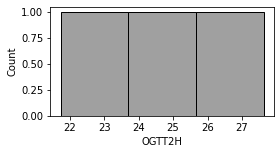

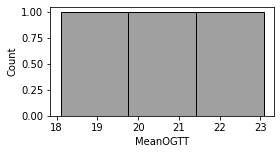

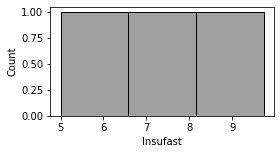

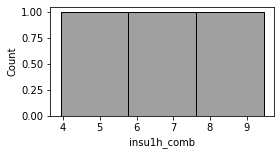

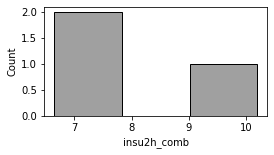

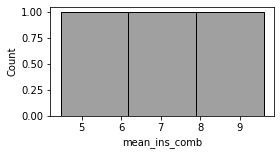

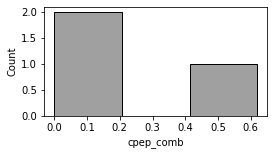

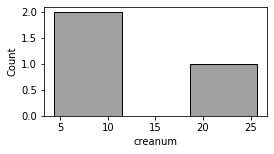

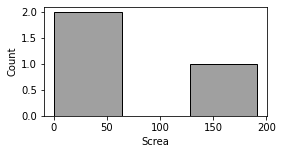

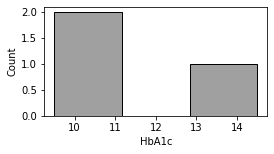

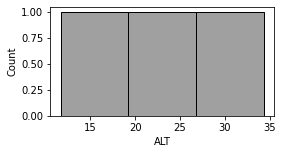

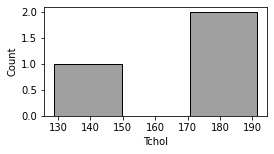

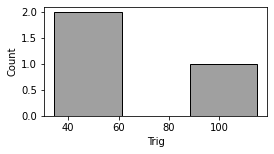

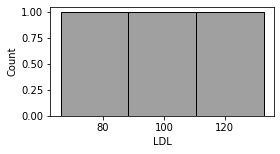

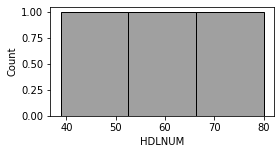

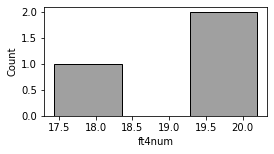

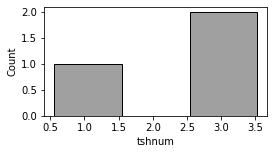

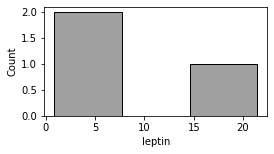

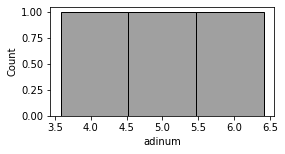

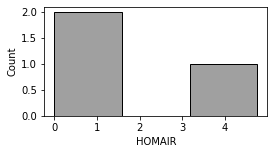

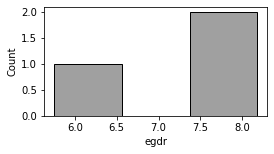

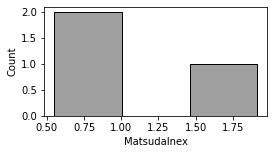

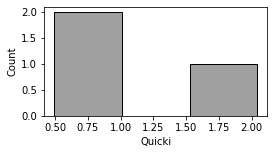

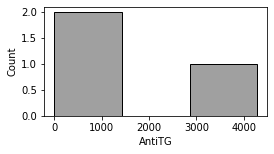

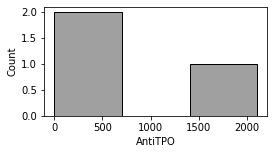

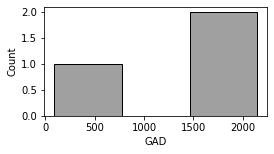

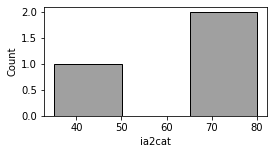

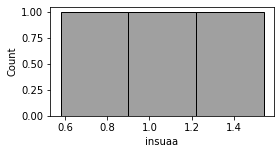

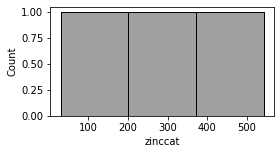

In [137]:
df_fifth = df[df['Segment'] == 'Fifth']
#taking only the numeric columns from the dataframe.

for i in df_fifth[numeric_features].columns:
    plt.figure(figsize=(4,2))
#     plt.title(i)
    sns.histplot(data=df_fifth[i], color='gray')

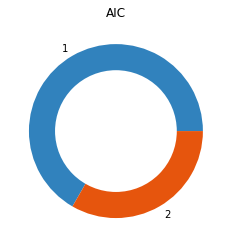

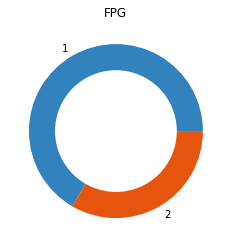

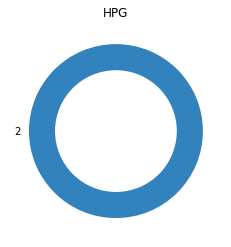

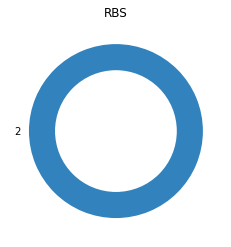

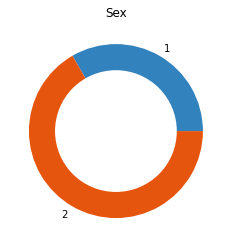

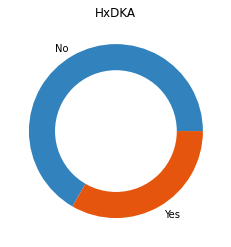

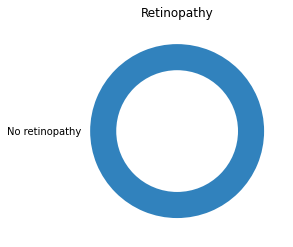

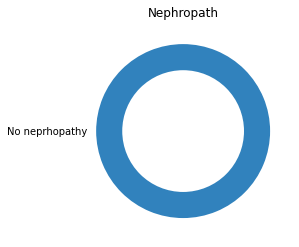

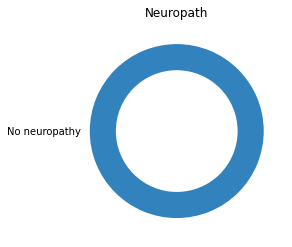

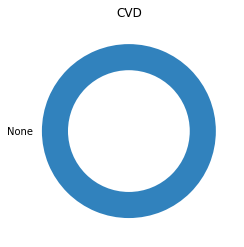

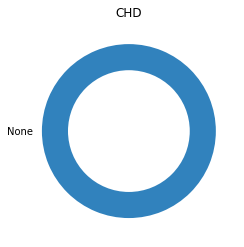

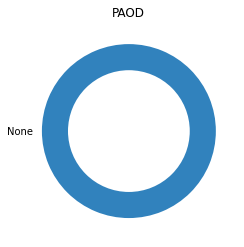

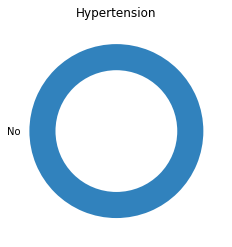

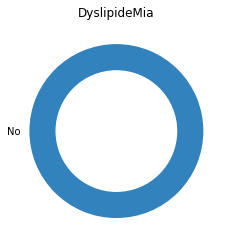

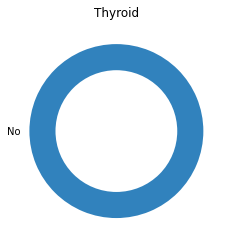

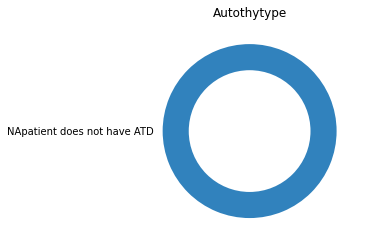

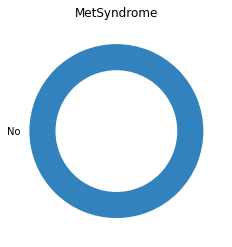

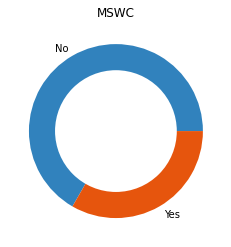

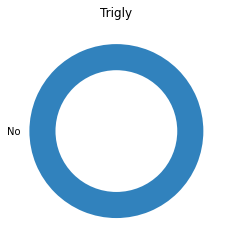

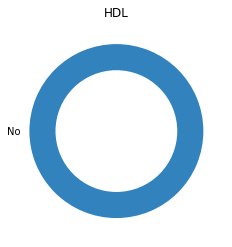

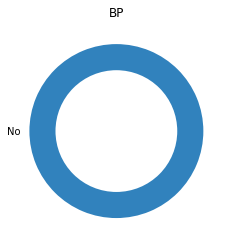

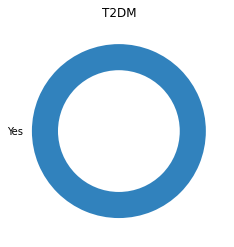

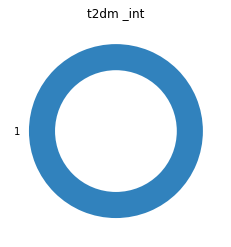

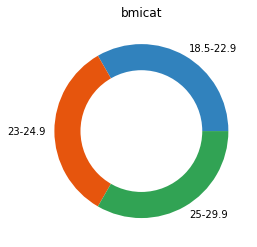

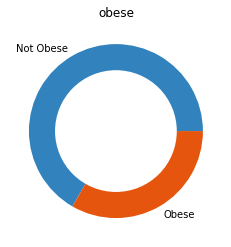

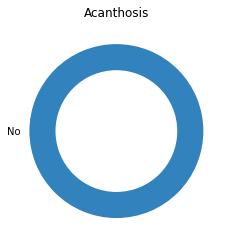

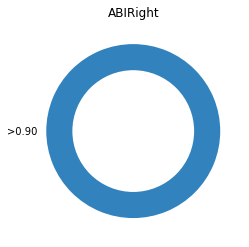

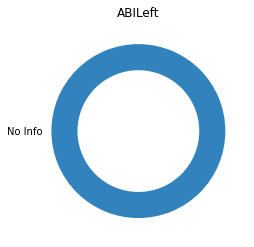

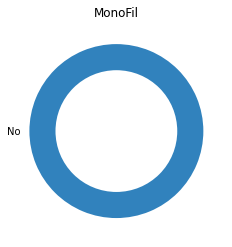

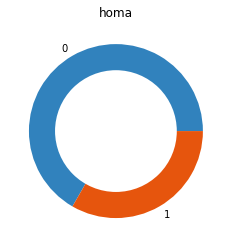

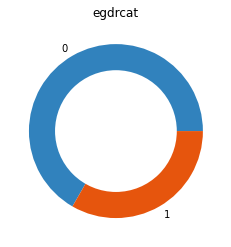

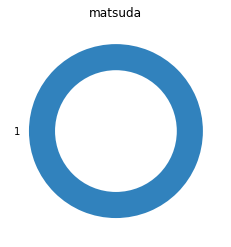

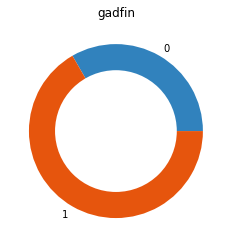

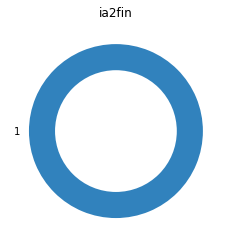

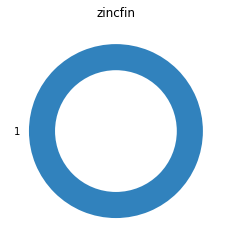

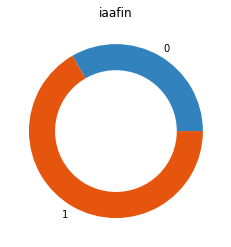

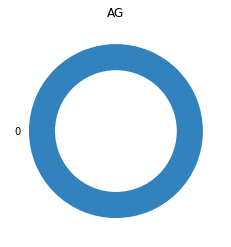

<Figure size 432x288 with 0 Axes>

In [138]:
for cols in column_categ:
    groupx = df_fifth.groupby([cols])[cols].count()

#     def absolute_value(val):
#         a = np.round(val/100.*groupx.sum(), 0)
#         return a

    cmap = plt.get_cmap("tab20c")
    plt.pie(groupx, labels=groupx.keys(), colors=cmap(np.arange(3)*4)) 
#     plt.pie(groupx, labels=groupx.keys(), colors=cmap(np.arange(3)*4), 
#             autopct=absolute_value)
    
    # draw circle
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()

    # Adding Circle in Pie chart
    fig.gca().add_artist(centre_circle)
    plt.title(cols)
    plt.figure().clear()

### Clusters Donut Chart

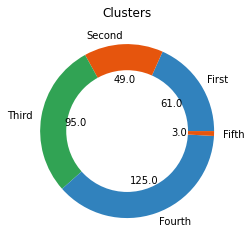

<Figure size 432x288 with 0 Axes>

In [141]:
clust = df.groupby(['Segment'])['Segment'].count()

def absolute_value(val):
    a = np.round(val/100.*clust.sum(), 0)
    return a

cmap = plt.get_cmap("tab20c")
# plt.pie(clust, labels=clust.keys(), colors=cmap(np.arange(3)*4)) 
plt.pie(clust, labels=clust.keys(), colors=cmap(np.arange(3)*4), 
        autopct=absolute_value)

# draw circle
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()

# Adding Circle in Pie chart
fig.gca().add_artist(centre_circle)
plt.title('Clusters')
plt.figure().clear()